# 09 — Qwen3.5-2B Binary Classification with Unsloth — Kaggle Edition

**Environment:** Kaggle Notebook with an NVIDIA CUDA GPU  
**Task:** predict `acute_rejection_within_30_days` from the established synthetic kidney-transplant assessments  
**Scope:** one baseline classifier only; no machine-unlearning method is implemented here

This notebook is a Kaggle-compatible duplicate of the Colab baseline. The research design is unchanged.

**GitHub workflow:** the research repository is cloned directly into Kaggle. For a private repository, store a read-capable GitHub token in Kaggle Secrets as `GITHUB_TOKEN`; the token is never printed or stored in the Git remote URL.


## Notebook pipeline

1. Check the Kaggle CUDA environment and clone the research project from GitHub.
2. Load the frozen dataset, feature contract and split memberships from the GitHub checkout.
3. Serialise the same 18 MLP features into deterministic text without the target or identifiers.
4. Load Qwen3.5-2B-Base with Unsloth and add LoRA plus a trainable two-class head.
5. Train on the training split and select the best checkpoint using validation PR-AUC.
6. Freeze a decision threshold using validation data only.
7. Evaluate the test split once and compare with the saved MLP baseline.
8. Save checkpoints and results under `/kaggle/working` and retain them with Kaggle Save Version/output files.


## 1. Purpose and Research Question

This notebook asks:

> **Can Qwen3.5-2B be fine-tuned efficiently as a binary classifier for acute kidney rejection prediction while maintaining a valid train/validation/test evaluation procedure?**

Class `0` means no confirmed acute rejection within 30 days; class `1` means confirmed acute rejection within 30 days. This is a baseline classification experiment. Full Retraining, Gradient Difference, SISA, retain-set fine-tuning and all other unlearning methods are deferred to a later notebook.

## 2. Relationship to the Existing Project

The main study uses a compact PyTorch MLP on the same synthetic longitudinal dataset. Its established utility measures are PR-AUC, balanced accuracy, binary cross-entropy (BCE), F1 and AUROC. The Qwen experiment is an extension, not a replacement: it reuses the target, approved features and frozen split memberships so that the final comparison is fair.

## 3. Why Qwen3.5-2B?

Qwen3.5-2B follows the supervisor's requested model family and size. Two billion parameters provide a meaningful LLM experiment while remaining feasible on a Kaggle NVIDIA GPU with parameter-efficient training. The Base variant is used because this experiment learns a new supervised classification head; instruction-following or chatbot behaviour is neither needed nor evaluated.

## 4. Why Kaggle and Unsloth?

Local Apple MPS training is not the intended environment. Kaggle provides CUDA-capable NVIDIA GPU runtimes, while Unsloth reduces the memory and compute cost of LoRA fine-tuning. Current Qwen3.5 guidance recommends 16-bit LoRA rather than 4-bit QLoRA. The notebook fails if CUDA is absent and never falls back to CPU or MPS.

This baseline deliberately uses one CUDA device even if Kaggle exposes two GPUs, keeping the methodology aligned with the original single-GPU experiment.


## 5. Classification Architecture

The design adapts the final-token classification principle in [gpjt/qwen-classifier](https://github.com/gpjt/qwen-classifier), not its spam dataset:

```text
serialised assessment
        ↓
     tokenizer
        ↓
 Qwen3.5-2B-Base + LoRA
        ↓
two logits at the final non-padding token
        ↓
 softmax probability → class 0 or class 1
```

The language-model output projection is replaced by a trainable linear layer with exactly two outputs. Cross-entropy is calculated directly from those two logits. Qwen is therefore a classifier, not a chatbot prompted to generate the text `0` or `1`.

## 6. Kaggle Environment Setup

Before running, enable **Internet** and select a **GPU accelerator** in Kaggle Notebook settings. Internet is required to clone GitHub, install Unsloth and download Qwen3.5-2B.

The installation below mirrors the working Qwen3.5-2B/Unsloth environment from the Colab version.


In [1]:
# Clone the research project from GitHub.
from pathlib import Path
import base64, shutil, subprocess

REPO_URL = "https://github.com/niamh-hughes/qub-machine-unlearning.git"
REPO_ROOT = Path("/kaggle/working/qub-machine-unlearning")

if REPO_ROOT.exists():
    shutil.rmtree(REPO_ROOT)

# For a private repo, create a Kaggle Secret named GITHUB_TOKEN.
github_token = None
try:
    from kaggle_secrets import UserSecretsClient
    github_token = UserSecretsClient().get_secret("GITHUB_TOKEN")
except Exception:
    github_token = None

cmd = ["git"]
if github_token:
    credentials = base64.b64encode(f"x-access-token:{github_token}".encode()).decode()
    cmd += ["-c", f"http.extraHeader=Authorization: Basic {credentials}"]
cmd += ["clone", REPO_URL, str(REPO_ROOT)]

try:
    subprocess.run(cmd, check=True)
except subprocess.CalledProcessError as exc:
    raise RuntimeError(
        "GitHub clone failed. Turn Kaggle Internet ON. For a private repo, "
        "add a Kaggle Secret named GITHUB_TOKEN with read access."
    ) from exc

print("Repository cloned:", REPO_ROOT)


Cloning into '/kaggle/working/qub-machine-unlearning'...


Repository cloned: /kaggle/working/qub-machine-unlearning


Updating files: 100% (5749/5749), done.


In [2]:
from pathlib import Path
import subprocess
REPO_ROOT = Path("/kaggle/working/qub-machine-unlearning")
print("Repository found:", REPO_ROOT.exists())
print("Commit:", subprocess.check_output(["git","-C",str(REPO_ROOT),"rev-parse","--short","HEAD"], text=True).strip())


Repository found: True
Commit: 96f37f6


In [3]:
# ============================================================
# Qwen3.5 + Unsloth environment setup for Kaggle
# Run ONCE in a fresh Kaggle GPU session.
# ============================================================

import os
import importlib.util

%pip install -q --upgrade uv

# Core Qwen3.5 / Unsloth stack.
# Torch 2.8.0 is used because this is the version expected by
# the current Unsloth Qwen3.5 Kaggle workflow.
!uv pip install -q \
    "torch==2.8.0" \
    "triton>=3.3.0" \
    torchvision \
    bitsandbytes \
    "xformers==0.0.32.post2" \
    pandas \
    numpy \
    scikit-learn \
    matplotlib \
    seaborn \
    datasets \
    safetensors \
    "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
    "unsloth[base] @ git+https://github.com/unslothai/unsloth"

# Supporting package versions used for Qwen3.5.
!uv pip install -q --upgrade --no-deps \
    "tokenizers>=0.22.0,<=0.23.0" \
    "trl==0.22.2" \
    unsloth \
    unsloth_zoo

# Qwen3.5 support in Transformers.
!uv pip install -q "transformers==5.2.0"

# Qwen3.5 sequence-model dependencies.
!uv pip install -q --no-build-isolation \
    flash-linear-attention \
    "causal_conv1d==1.6.0"

# IMPORTANT:
# TorchAO must be compatible with Torch 2.8.0.
# TorchAO 0.13.0 is the release matched to PyTorch 2.8.
# !uv pip uninstall -y torchao
# !uv pip install -q --no-deps "torchao==0.13.0"

# TorchAO is not required for this LoRA classification experiment.
# Remove Kaggle's pre-installed copy so incompatible TorchAO imports
# do not interfere with Transformers / PEFT.
!uv pip uninstall torchao

# A T4 is pre-Ampere, so TileLang kernels should be disabled.
import torch

if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] < 8:
    os.environ["FLA_TILELANG"] = "0"

print("Environment installation complete.")
print("IMPORTANT: Restart the Kaggle session before continuing.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 82.0 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.13 environment at: /usr
Uninstalled 1 package in 134ms
 - torchao==0.18.0
Environment installation complete.
IMPORTANT: Restart the Kaggle session before continuing.


In [4]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from transformers import AutoProcessor

print("AutoProcessor import: OK")

PyTorch: 2.8.0+cu128
Transformers: 5.2.0
CUDA available: True
GPU: Tesla T4
AutoProcessor import: OK


In [5]:
import importlib.metadata
import platform
import sys

import torch
import transformers


def show_gpu_information() -> dict:
    "Return and print the runtime versions and CUDA hardware."
    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA is unavailable. In Kaggle Notebook settings choose a GPU accelerator, "
            "then restart and run from the top. CPU and MPS fallback are not allowed."
        )
    properties = torch.cuda.get_device_properties(0)
    details = {
        "Python": sys.version.split()[0],
        "PyTorch": torch.__version__,
        "Transformers": transformers.__version__,
        "Unsloth": importlib.metadata.version("unsloth"),
        "Platform": platform.platform(),
        "CUDA available": True,
        "GPU": properties.name,
        "Visible CUDA GPUs": torch.cuda.device_count(),
        "GPU memory (GiB)": round(properties.total_memory / 1024**3, 2),
    }
    return details


environment_info = show_gpu_information()
display(pd.Series(environment_info, name="Value").to_frame()) if "pd" in globals() else print(environment_info)
DEVICE = torch.device("cuda")

{'Python': '3.12.13', 'PyTorch': '2.8.0+cu128', 'Transformers': '5.2.0', 'Unsloth': '2026.8.21', 'Platform': 'Linux-6.12.90+-x86_64-with-glibc2.35', 'CUDA available': True, 'GPU': 'Tesla T4', 'Visible CUDA GPUs': 2, 'GPU memory (GiB)': 14.56}


## 7. Kaggle Working Storage

Project inputs are read from the GitHub checkout under `/kaggle/working/qub-machine-unlearning`. Generated checkpoints and results are written under `/kaggle/working/qwen35_classifier_kaggle`. Use **Save Version** with outputs enabled, or download the output folder after the run. Large Qwen checkpoints are not pushed back to GitHub automatically.


In [6]:
from pathlib import Path
KAGGLE_WORKING_ROOT = Path("/kaggle/working")
assert KAGGLE_WORKING_ROOT.exists()
print("Kaggle working directory:", KAGGLE_WORKING_ROOT)


Kaggle working directory: /kaggle/working


In [7]:
from datetime import datetime, timezone
from pathlib import Path

REPO_ROOT = Path("/kaggle/working/qub-machine-unlearning")
KAGGLE_OUTPUT_ROOT = Path("/kaggle/working/qwen35_classifier_kaggle")
MODEL_ROOT = KAGGLE_OUTPUT_ROOT / "models"
RESULT_ROOT = KAGGLE_OUTPUT_ROOT / "results"
CHECKPOINT_ROOT = MODEL_ROOT / "checkpoints"
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
RUN_MODEL_DIR = MODEL_ROOT / RUN_ID
RUN_RESULT_DIR = RESULT_ROOT / RUN_ID
BEST_ADAPTER_DIR = CHECKPOINT_ROOT / RUN_ID / "best_adapter"
for path in [RUN_MODEL_DIR, RUN_RESULT_DIR, BEST_ADAPTER_DIR.parent]:
    path.mkdir(parents=True, exist_ok=True)
paths = {"GitHub checkout": REPO_ROOT, "models": RUN_MODEL_DIR, "results": RUN_RESULT_DIR, "checkpoints": BEST_ADAPTER_DIR.parent}
display(pd.Series({k: str(v) for k, v in paths.items()}, name="Kaggle path").to_frame()) if "pd" in globals() else print(paths)


{'GitHub checkout': PosixPath('/kaggle/working/qub-machine-unlearning'), 'models': PosixPath('/kaggle/working/qwen35_classifier_kaggle/models/20260827T080825Z'), 'results': PosixPath('/kaggle/working/qwen35_classifier_kaggle/results/20260827T080825Z'), 'checkpoints': PosixPath('/kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z')}


## 8. Reproducibility

Random sources are seeded before data loading and training. CUDA operations can still vary across drivers, kernels and GPU models, so this improves repeatability without claiming perfect bit-for-bit determinism.

In [8]:
import json
import os
import random
import time

import numpy as np
import pandas as pd

SEED = 42


def set_reproducible_seed(seed: int) -> None:
    "Seed Python, NumPy and PyTorch without promising perfect GPU determinism."
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_reproducible_seed(SEED)
print(f"Random seed: {SEED}")

Random seed: 42


## 9. Load the Established Dataset

No records are generated here and no remote inference API is called. The input is the immutable synthetic assessment table already assembled by the project. Identifiers are used only to verify joins and split membership; they are not displayed as model inputs.

In [9]:
# ============================================================
# Load the established project inputs from the GitHub checkout
# ============================================================

from pathlib import Path
import json
import pandas as pd

# The full research repository should have been cloned here
REPO_ROOT = Path("/kaggle/working/qub-machine-unlearning")

# Existing final-submission folders inside the repository
FINAL_SUBMISSION_DIR = REPO_ROOT / "code" / "final_submission"

DATA_DIR = FINAL_SUBMISSION_DIR / "data" / "final"
PROCESSED_DIR = FINAL_SUBMISSION_DIR / "processed_data"
MLP_RESULTS_DIR = FINAL_SUBMISSION_DIR / "results" / "baseline"

# Use the existing frozen project artefacts.
# These are the same inputs used by the established MLP experiment.
ASSESSMENT_PATH = DATA_DIR / "kidney_transplant_assessments.csv"
FEATURE_CONTRACT_PATH = DATA_DIR / "classifier_feature_list.json"
SPLIT_PATH = PROCESSED_DIR / "split_assignments.csv"
MLP_METRICS_PATH = MLP_RESULTS_DIR / "test_metrics.csv"

required_inputs = [
    ASSESSMENT_PATH,
    FEATURE_CONTRACT_PATH,
    SPLIT_PATH,
    MLP_METRICS_PATH,
]

# Show exactly where Kaggle is looking before continuing.
input_check = pd.DataFrame({
    "Artefact": [
        "Kidney transplant assessments",
        "Classifier feature contract",
        "Frozen split assignments",
        "MLP test metrics",
    ],
    "Path": [str(path) for path in required_inputs],
    "Exists": [path.exists() for path in required_inputs],
})

display(input_check)

# Stop before training if any established project input is unavailable.
missing_inputs = [
    str(path) for path in required_inputs if not path.exists()
]

if missing_inputs:
    raise FileNotFoundError(
        "Required project files are missing from the cloned GitHub repository:\n"
        + "\n".join(missing_inputs)
    )

# Load the established dataset and classifier feature contract.
assessments = pd.read_csv(ASSESSMENT_PATH)

feature_contract = json.loads(
    FEATURE_CONTRACT_PATH.read_text(encoding="utf-8")
)

TARGET = feature_contract["target"]

# Brief check that the expected dataset has been loaded.
dataset_summary = {
    "assessment rows": len(assessments),
    "columns": assessments.shape[1],
    "recipients": assessments["recipient_id"].nunique(),
    "class 0": int((assessments[TARGET] == 0).sum()),
    "class 1": int((assessments[TARGET] == 1).sum()),
    "positive prevalence": float(assessments[TARGET].mean()),
}

display(pd.Series(dataset_summary, name="Value").to_frame())

,Artefact,Path,Exists
0,Kidney transplant assessments,/kaggle/working/qub-machine-unlearning/code/fi...,True
1,Classifier feature contract,/kaggle/working/qub-machine-unlearning/code/fi...,True
2,Frozen split assignments,/kaggle/working/qub-machine-unlearning/code/fi...,True
3,MLP test metrics,/kaggle/working/qub-machine-unlearning/code/fi...,True


,Value
assessment rows,60000.0000
columns,31.0000
recipients,10000.0000
class 0,55506.0000
class 1,4494.0000
positive prevalence,0.0749


## 10. Reuse the Frozen Train / Validation / Test Split

The saved membership file is joined by `recipient_id`; no random split function is called. Identical memberships are necessary because changing recipients or donors between partitions would confound comparison with the MLP.

In [10]:
split_assignments = pd.read_csv(SPLIT_PATH)
assert split_assignments["recipient_id"].is_unique
assert set(split_assignments["split"]) == {"train", "validation", "test"}

data = assessments.merge(
    split_assignments[["recipient_id", "donor_id", "split"]],
    on=["recipient_id", "donor_id"],
    how="left",
    validate="many_to_one",
)
assert data["split"].notna().all()
assert len(data) == len(assessments) == 60_000

split_frames = {
    name: data.loc[data["split"].eq(name)].reset_index(drop=True)
    for name in ["train", "validation", "test"]
}

expected_rows = {"train": 42_024, "validation": 8_988, "test": 8_988}
assert {name: len(frame) for name, frame in split_frames.items()} == expected_rows
assert sum(expected_rows.values()) == len(data)

for key in ["assessment_id", "recipient_id", "donor_id"]:
    memberships = {name: set(frame[key]) for name, frame in split_frames.items()}
    assert memberships["train"].isdisjoint(memberships["validation"])
    assert memberships["train"].isdisjoint(memberships["test"])
    assert memberships["validation"].isdisjoint(memberships["test"])

assert data.groupby("recipient_id")["split"].nunique().max() == 1
assert data.groupby("donor_id")["split"].nunique().max() == 1
ORIGINAL_SPLITS_REUSED = True

split_summary = pd.DataFrame([
    {
        "split": name,
        "assessments": len(frame),
        "recipients": frame["recipient_id"].nunique(),
        "donors": frame["donor_id"].nunique(),
        "positives": int(frame[TARGET].sum()),
        "prevalence": frame[TARGET].mean(),
    }
    for name, frame in split_frames.items()
])
display(split_summary)

,split,assessments,recipients,donors,positives,prevalence
0,train,42024,7004,5601,3160,0.075195
1,validation,8988,1498,1199,669,0.074433
2,test,8988,1498,1200,665,0.073988


In [11]:
# ============================================================
# Fixed training subset for the Qwen3.5-2B extension
# ============================================================
# The main MLP study uses the complete frozen training split.
# Qwen3.5-2B is much more computationally expensive, so this
# extension uses a deterministic recipient-level subset.
#
# Validation and test sets remain unchanged.

LLM_TRAIN_RECIPIENTS = 2000

# Keep recipient-level longitudinal structure intact:
# if a recipient is selected, all of their training assessments are kept.
available_train_recipients = (
    split_frames["train"]["recipient_id"]
    .drop_duplicates()
    .sort_values()
)

assert len(available_train_recipients) >= LLM_TRAIN_RECIPIENTS

selected_llm_recipients = (
    available_train_recipients
    .iloc[:LLM_TRAIN_RECIPIENTS]
)

FULL_TRAIN_ROWS = len(split_frames["train"])
FULL_TRAIN_RECIPIENTS = split_frames["train"]["recipient_id"].nunique()

split_frames["train"] = (
    split_frames["train"]
    .loc[
        split_frames["train"]["recipient_id"].isin(
            selected_llm_recipients
        )
    ]
    .copy()
    .reset_index(drop=True)
)

print("Original training recipients:", FULL_TRAIN_RECIPIENTS)
print("Original training rows:", FULL_TRAIN_ROWS)
print()
print(
    "Qwen training recipients:",
    split_frames["train"]["recipient_id"].nunique(),
)
print(
    "Qwen training rows:",
    len(split_frames["train"]),
)
print(
    "Validation rows unchanged:",
    len(split_frames["validation"]),
)
print(
    "Test rows unchanged:",
    len(split_frames["test"]),
)

assert (
    split_frames["train"]["recipient_id"].nunique()
    == LLM_TRAIN_RECIPIENTS
)

assert len(split_frames["validation"]) == 8988
assert len(split_frames["test"]) == 8988

Original training recipients: 7004
Original training rows: 42024

Qwen training recipients: 2000
Qwen training rows: 12000
Validation rows unchanged: 8988
Test rows unchanged: 8988


## 11. Define the Approved Input Features

The JSON feature contract is authoritative. Qwen receives exactly the same 18 predictive fields as the MLP, only encoded as text. Identifiers, consent/retention fields, dates, hospital information and the target are blocked explicitly.

In [12]:
FEATURES = feature_contract["classifier_features"]
EXPECTED_FEATURES = [
    "recipient_age", "donor_age", "donor_type", "kidney_failure_cause",
    "previous_transplant", "dialysis_months", "abo_compatibility_category",
    "hla_mismatch_count", "antibody_risk_score", "cold_ischaemia_hours",
    "days_since_transplant", "creatinine_mg_dl", "creatinine_change_pct",
    "urine_output_ml_24h", "tacrolimus_level_ng_ml",
    "medication_adherence_pct", "infection_indicator", "previous_rejection",
]
BLOCKED_COLUMNS = {
    "assessment_id", "recipient_id", "donor_id", "hospital_id", "assessment_date",
    "training_consent_status", "training_consent_version", "retention_expiry_date", TARGET,
}

assert FEATURES == EXPECTED_FEATURES
assert len(FEATURES) == 18
assert set(FEATURES).isdisjoint(BLOCKED_COLUMNS)
assert set(FEATURES).issubset(assessments.columns)
display(pd.DataFrame({"position": range(1, len(FEATURES) + 1), "approved feature": FEATURES}))

,position,approved feature
0,1,recipient_age
1,2,donor_age
2,3,donor_type
3,4,kidney_failure_cause
4,5,previous_transplant
5,6,dialysis_months
6,7,abo_compatibility_category
7,8,hla_mismatch_count
8,9,antibody_risk_score
9,10,cold_ischaemia_hours


## 12. Deterministic Tabular-to-Text Serialisation

A language model needs a token sequence, so each row is converted to short field-value statements in one fixed order. The serializer adds no clinical interpretation. The target remains separate, and identifiers never enter the text.

In [13]:
FEATURE_LABELS = {
    "recipient_age": "Recipient age (years)",
    "donor_age": "Donor age (years)",
    "donor_type": "Donor type",
    "kidney_failure_cause": "Kidney failure cause",
    "previous_transplant": "Previous transplant",
    "dialysis_months": "Dialysis duration (months)",
    "abo_compatibility_category": "ABO compatibility",
    "hla_mismatch_count": "HLA mismatch count",
    "antibody_risk_score": "Antibody risk score",
    "cold_ischaemia_hours": "Cold ischaemia time (hours)",
    "days_since_transplant": "Days since transplant",
    "creatinine_mg_dl": "Creatinine (mg/dL)",
    "creatinine_change_pct": "Creatinine change (percent)",
    "urine_output_ml_24h": "Urine output (mL/24h)",
    "tacrolimus_level_ng_ml": "Tacrolimus level (ng/mL)",
    "medication_adherence_pct": "Medication adherence (percent)",
    "infection_indicator": "Infection indicator",
    "previous_rejection": "Previous rejection",
}
BINARY_FEATURES = {"previous_transplant", "infection_indicator", "previous_rejection"}
SERIALISATION_VERSION = "kidney-qwen35-v1"


def format_feature_value(feature: str, value) -> str:
    "Format one stored feature deterministically without adding information."
    if pd.isna(value):
        return "missing"
    if feature in BINARY_FEATURES:
        return "yes" if int(value) == 1 else "no"
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.4f}".rstrip("0").rstrip(".")
    return str(value).strip()


def serialize_assessment(row: pd.Series) -> str:
    "Serialise exactly the approved features in their frozen order."
    return "\n".join(
        f"{FEATURE_LABELS[feature]}: {format_feature_value(feature, row[feature])}."
        for feature in FEATURES
    )


for name, frame in split_frames.items():
    frame["text"] = frame.apply(serialize_assessment, axis=1)

NO_TARGET_LEAKAGE = all(
    TARGET not in text
    and all(blocked not in text for blocked in BLOCKED_COLUMNS)
    for frame in split_frames.values()
    for text in frame["text"]
)
assert NO_TARGET_LEAKAGE

example_zero = split_frames["train"].loc[split_frames["train"][TARGET].eq(0), "text"].iloc[0]
example_one = split_frames["train"].loc[split_frames["train"][TARGET].eq(1), "text"].iloc[0]
print("CLASS 0 EXAMPLE\n", example_zero, "\n\nCLASS 1 EXAMPLE\n", example_one)

CLASS 0 EXAMPLE
 Recipient age (years): 59.
Donor age (years): 46.
Donor type: Deceased.
Kidney failure cause: Polycystic kidney disease.
Previous transplant: no.
Dialysis duration (months): 4.
ABO compatibility: Managed incompatibility.
HLA mismatch count: 5.
Antibody risk score: 0.884.
Cold ischaemia time (hours): 4.62.
Days since transplant: 60.
Creatinine (mg/dL): 1.22.
Creatinine change (percent): -9.6296.
Urine output (mL/24h): 2280.
Tacrolimus level (ng/mL): 8.9.
Medication adherence (percent): 91.
Infection indicator: no.
Previous rejection: yes. 

CLASS 1 EXAMPLE
 Recipient age (years): 59.
Donor age (years): 46.
Donor type: Deceased.
Kidney failure cause: Polycystic kidney disease.
Previous transplant: no.
Dialysis duration (months): 4.
ABO compatibility: Managed incompatibility.
HLA mismatch count: 5.
Antibody risk score: 0.884.
Cold ischaemia time (hours): 4.62.
Days since transplant: 7.
Creatinine (mg/dL): 1.24.
Creatinine change (percent): -3.6519.
Urine output (mL/24h): 

## 13. Prepare Classification Labels

Labels are integer tensors stored separately from text. The model is trained to minimise two-class cross-entropy, not to generate a label string.

In [14]:
for name, frame in split_frames.items():
    assert set(frame[TARGET].unique()).issubset({0, 1})
    frame["label"] = frame[TARGET].astype("int64")

assert TARGET not in FEATURES
print("Labels:", {0: "no acute rejection within 30 days", 1: "acute rejection within 30 days"})

Labels: {0: 'no acute rejection within 30 days', 1: 'acute rejection within 30 days'}


## 14. Tokenisation

Sequence length is selected from training text only. The maximum observed training length is rounded up to a multiple of eight, with a 512-token safety ceiling. Validation and test text can be measured for transparent truncation reporting, but their labels do not affect this choice.

In [15]:
from transformers import AutoProcessor

MODEL_ID = "unsloth/Qwen3.5-2B-Base"

# Load only the processor for length inspection; model weights are not needed yet.
processor = AutoProcessor.from_pretrained(MODEL_ID)
text_tokenizer = getattr(processor, "tokenizer", processor)
text_tokenizer.padding_side = "right"
if text_tokenizer.pad_token_id is None:
    text_tokenizer.pad_token = text_tokenizer.eos_token


def token_lengths(texts: list[str], batch_size: int = 512) -> np.ndarray:
    "Measure untruncated token counts in bounded batches."
    lengths = []
    for start in range(0, len(texts), batch_size):
        encoded = text_tokenizer(
            texts[start:start + batch_size], add_special_tokens=True,
            truncation=False, padding=False,
        )["input_ids"]
        lengths.extend(map(len, encoded))
    return np.asarray(lengths)


train_lengths = token_lengths(split_frames["train"]["text"].tolist())
MAX_SEQ_LENGTH = min(512, int(np.ceil(train_lengths.max() / 8) * 8))

length_rows = []
for name, frame in split_frames.items():
    lengths = train_lengths if name == "train" else token_lengths(frame["text"].tolist())
    frame["token_length"] = lengths
    length_rows.append({
        "split": name,
        "minimum": int(lengths.min()),
        "median": float(np.median(lengths)),
        "95th percentile": float(np.percentile(lengths, 95)),
        "maximum": int(lengths.max()),
        "truncated": int((lengths > MAX_SEQ_LENGTH).sum()),
    })

display(pd.DataFrame(length_rows))
print(f"Chosen maximum sequence length: {MAX_SEQ_LENGTH} tokens (derived from training text only)")

processor_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.69k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 20.0MB            

tokenizer.json: downloading bytes:           |  0.00B            

,split,minimum,median,95th percentile,maximum,truncated
0,train,188,200.0,204.0,209,0
1,validation,188,200.0,204.0,209,0
2,test,189,200.0,204.0,209,0


Chosen maximum sequence length: 216 tokens (derived from training text only)


## 15. Load Qwen3.5-2B with Unsloth

The exact Base checkpoint is loaded into the Kaggle CUDA runtime in 16-bit mode. No Qwen API, alternate model or MPS device is used. The visual encoder remains frozen because the input is text only.


In [16]:
# Release the temporary processor reference before the full model is created.
del processor
torch.cuda.empty_cache()

from unsloth import FastVisionModel

model, processor = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=False,
    load_in_16bit=True,
    max_seq_length=MAX_SEQ_LENGTH,
    use_gradient_checkpointing=False,
)
text_tokenizer = getattr(processor, "tokenizer", processor)
text_tokenizer.padding_side = "right"
if text_tokenizer.pad_token_id is None:
    text_tokenizer.pad_token = text_tokenizer.eos_token

assert "Qwen3.5-2B" in MODEL_ID
assert next(model.parameters()).is_cuda
print("Loaded model:", MODEL_ID)

/usr/local/lib/python3.12/dist-packages/unsloth/_gpu_init.py:98: UserWarning: Unsloth: torchaudio cannot initialise against this torch and has been disabled for this process, so anything that needs it will report it as missing rather than crash at import. Install the matching wheel to restore it. Original error: /usr/local/lib/python3.12/dist-packages/torchaudio/lib/libtorchaudio.so: undefined symbol: aoti_torch_create_device_guard
  disable_torchaudio_if_cuda_mismatched()
/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:1531: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/_gpu_init.py:264: UserWarning: torchcodec 0.10.0+cu128 is incompatible with torch 2.8.0+cu128; install a matching build with `pip install 'torchcodec>=0.7,<0.8.0'`.
  disable_torchcodec_if_broken()


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.21: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
total weights      : 4.122 GiB
no_split classes   : ['Qwen3_5DecoderLayer', 'Qwen3_5TextDecoderLayer', 'Qwen3_5VisionBlock']
output head        : lm_head -> cuda:1
head headroom      : 0.428 GiB
activation reserve : 12.176 GiB requested
tied to head       : ['model.language_model.embed_tokens']
  cuda:0  budget  14.44 GiB  weights  2.225 GiB  free 12.217 GiB  reserve 12.176 GiB
  cuda:1  budget  14.46 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

Loaded model: unsloth/Qwen3.5-2B-Base


## 16. Add Parameter-Efficient Fine-Tuning

Qwen3.5 combines full-attention and gated linear-attention layers. Restricting LoRA to only `q_proj` and `v_proj` would miss much of this hybrid backbone. Current Unsloth guidance therefore supports `all-linear`; the classification head is excluded from LoRA and stored as a fully trainable module. Rank 16, alpha 16, zero LoRA dropout and Unsloth gradient checkpointing form a conservative first baseline.

## 17. Create the Binary Classification Head

The original vocabulary projection is replaced before LoRA is attached. `modules_to_save=["lm_head"]` instructs PEFT to train and persist this non-LoRA module with the adapter. A real forward pass below verifies the required `[batch_size, 2]` output.

In [17]:
from torch import nn
import torch.nn.functional as F


class FP32ClassificationHead(nn.Linear):
    """
    Two-class classification head kept in FP32 for stable training.

    Qwen produces FP16 hidden states on the T4. The input is therefore
    explicitly converted to FP32 before applying the trainable head.
    """

    def forward(self, hidden_states):
        return F.linear(
            hidden_states.float(),
            self.weight,
            self.bias,
        )


original_output_head = model.get_output_embeddings()

hidden_size = original_output_head.in_features
head_device = original_output_head.weight.device

# Keep the trainable classification head in FP32.
binary_head = FP32ClassificationHead(
    hidden_size,
    2,
    bias=False,
    device=head_device,
    dtype=torch.float32,
)

nn.init.normal_(
    binary_head.weight,
    mean=0.0,
    std=0.02,
)

model.set_output_embeddings(binary_head)

model.config.num_labels = 2
model.config.pad_token_id = text_tokenizer.pad_token_id

print("Classification head created.")
print("Hidden size:", hidden_size)
print("Output classes:", model.get_output_embeddings().out_features)
print("Head dtype:", model.get_output_embeddings().weight.dtype)
print("Head device:", model.get_output_embeddings().weight.device)

assert model.get_output_embeddings().weight.dtype == torch.float32
assert model.get_output_embeddings().out_features == 2

Classification head created.
Hidden size: 2048
Output classes: 2
Head dtype: torch.float32
Head device: cuda:1


In [18]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    target_modules="all-linear",
    modules_to_save=["lm_head"],
    r=16, lora_alpha=16, lora_dropout=0, bias="none",
    use_gradient_checkpointing= False, random_state=SEED,
    use_rslora=False, loftq_config=None,
)
model.config.use_cache = False

# Keep trainable LoRA parameters and the classification head in FP32.
# The frozen Qwen backbone remains in 16-bit for memory efficiency.
for parameter in model.parameters():
    if parameter.requires_grad:
        parameter.data = parameter.data.float()

trainable_dtypes = {}
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        trainable_dtypes.setdefault(str(parameter.dtype), 0)
        trainable_dtypes[str(parameter.dtype)] += parameter.numel()
print("Trainable parameter dtypes:", trainable_dtypes)
assert not [name for name, p in model.named_parameters() if p.requires_grad and p.dtype == torch.float16]


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
[unsloth_zoo.log|WARNING]Unsloth: Failed to register input-embedding hook for `model.base_model.model.model.visual`: `get_input_embeddings` not auto‑handled for Qwen3_5VisionModel; please override in the subclass.. Falling back to pre-forward hook.


Unsloth: Allowing gradients for `base_model.model.lm_head` since it's in `modules_to_save`.
Trainable parameter dtypes: {'torch.float32': 23114752}


In [19]:
smoke_text = split_frames["train"]["text"].iloc[:2].tolist()
smoke_inputs = text_tokenizer(
    smoke_text, padding=True, truncation=True,
    max_length=MAX_SEQ_LENGTH, return_tensors="pt",
).to(DEVICE)

with torch.no_grad():
    smoke_sequence_logits = model(**smoke_inputs).logits
smoke_last_indices = smoke_inputs["attention_mask"].sum(dim=1) - 1
smoke_logits = smoke_sequence_logits[
    torch.arange(len(smoke_text), device=DEVICE), smoke_last_indices
]

assert smoke_logits.shape == (2, 2)
assert torch.isfinite(smoke_logits).all()
LOGITS_SHAPE_VERIFIED = True
print("Final-token logits shape:", tuple(smoke_logits.shape))
print("Final-token logits dtype:", smoke_logits.dtype)
del smoke_inputs, smoke_sequence_logits, smoke_logits

Final-token logits shape: (2, 2)
Final-token logits dtype: torch.float32


## 18. Inspect Trainable Parameters

Only LoRA adapter weights and the two-class head should update. The visual encoder and original Qwen weights remain frozen.

In [20]:
parameter_rows = []
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        family = "classification head" if "lm_head" in name else "LoRA" if "lora_" in name else "other"
        parameter_rows.append({"name": name, "parameters": parameter.numel(), "family": family})

trainable_parameters = sum(row["parameters"] for row in parameter_rows)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
frozen_parameters = total_parameters - trainable_parameters
head_was_trainable = any(row["family"] == "classification head" for row in parameter_rows)
assert head_was_trainable
assert all(row["family"] in {"classification head", "LoRA"} for row in parameter_rows)

parameter_summary = pd.DataFrame([
    {"category": "total", "parameters": total_parameters},
    {"category": "trainable", "parameters": trainable_parameters},
    {"category": "frozen", "parameters": frozen_parameters},
    {"category": "LoRA trainable", "parameters": sum(r["parameters"] for r in parameter_rows if r["family"] == "LoRA")},
    {"category": "head trainable", "parameters": sum(r["parameters"] for r in parameter_rows if r["family"] == "classification head")},
])
parameter_summary["percent of total"] = 100 * parameter_summary["parameters"] / total_parameters
display(parameter_summary)

,category,parameters,percent of total
0,total,2236360512,100.000000
1,trainable,23114752,1.033588
2,frozen,2213245760,98.966412
3,LoRA trainable,23110656,1.033405
4,head trainable,4096,0.000183


## 19. Class Imbalance Handling

Acute rejection is uncommon. Class weights are calculated from training labels only and used only in the training loss. Validation and test BCE remain unweighted so they describe probability quality on the observed distributions.

In [21]:
from sklearn.utils.class_weight import compute_class_weight

y_train = split_frames["train"]["label"].to_numpy()
class_weight_values = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
CLASS_WEIGHTS = torch.tensor(class_weight_values, dtype=torch.float32, device=DEVICE)
display(pd.DataFrame({"class": [0, 1], "training weight": class_weight_values}))

,class,training weight
0,0,0.540882
1,1,6.615215


## 20. Training Configuration

This is one conservative baseline, not a hyperparameter search. A physical batch of four and eight accumulation steps give an effective batch of 32. Validation PR-AUC selects the checkpoint because it is informative under class imbalance.

In [22]:
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
LEARNING_RATE = 2e-5
MAX_EPOCHS = 3
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2
GRADIENT_CLIP_NORM = 1.0

training_configuration = {
    "model": MODEL_ID,
    "batch size": BATCH_SIZE,
    "effective batch size": EFFECTIVE_BATCH_SIZE,
    "learning rate": LEARNING_RATE,
    "maximum epochs": MAX_EPOCHS,
    "LoRA rank": 16,
    "LoRA alpha": 16,
    "LoRA dropout": 0,
    "LoRA targets": "all linear language layers (hybrid Qwen3.5 coverage)",
    "maximum sequence length": MAX_SEQ_LENGTH,
    "optimiser": "AdamW",
    "weight decay": WEIGHT_DECAY,
    "early stopping patience": EARLY_STOPPING_PATIENCE,
    "selection metric": "validation PR-AUC (higher is better)",
    "random seed": SEED,
}
display(pd.Series(training_configuration, name="Value").to_frame())

,Value
model,unsloth/Qwen3.5-2B-Base
batch size,8
effective batch size,32
learning rate,0.00002
maximum epochs,3
LoRA rank,16
LoRA alpha,16
LoRA dropout,0
LoRA targets,all linear language layers (hybrid Qwen3.5 cov...
maximum sequence length,216


## 21. Baseline Training

The data loader tokenises with dynamic right padding. The training loop never receives the test frame or test loader. A live progress bar reports batch progress, running loss and learning rate; after each epoch, validation PR-AUC selects the best checkpoint saved under `/kaggle/working`.


In [23]:
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset


class AssessmentTextDataset(Dataset):
    "Minimal text/label dataset; identifiers are returned only for saved predictions."

    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["text"].tolist()
        self.labels = frame["label"].astype(int).tolist()
        self.assessment_ids = frame["assessment_id"].astype(str).tolist()

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> dict:
        return {
            "text": self.texts[index],
            "label": self.labels[index],
            "assessment_id": self.assessment_ids[index],
        }


def collate_assessments(rows: list[dict]) -> dict:
    "Tokenise one batch without putting labels into its input text."
    encoded = text_tokenizer(
        [row["text"] for row in rows],
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors="pt",
    )
    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "labels": torch.tensor([row["label"] for row in rows], dtype=torch.long),
        "assessment_id": [row["assessment_id"] for row in rows],
    }


generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    AssessmentTextDataset(split_frames["train"]), batch_size=BATCH_SIZE,
    shuffle=True, generator=generator, collate_fn=collate_assessments, num_workers=0,
)
validation_loader = DataLoader(
    AssessmentTextDataset(split_frames["validation"]), batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_assessments, num_workers=0,
)

# The test loader is deliberately not created until Section 24.
TEST_EVALUATION_STARTED = False
TEST_ROWS_USED_FOR_TRAINING = 0

In [24]:
from sklearn.metrics import average_precision_score


def final_token_logits(model_object, batch: dict) -> torch.Tensor:
    "Return two logits at each sequence's final non-padding token."
    input_ids = batch["input_ids"].to(DEVICE)
    attention_mask = batch["attention_mask"].to(DEVICE)
    sequence_logits = model_object(input_ids=input_ids, attention_mask=attention_mask).logits
    final_indices = attention_mask.sum(dim=1) - 1
    logits = sequence_logits[torch.arange(input_ids.shape[0], device=DEVICE), final_indices]
    if logits.shape != (input_ids.shape[0], 2):
        raise RuntimeError(f"Expected [batch, 2] logits, received {tuple(logits.shape)}")
    return logits


@torch.no_grad()
def evaluate_classifier(model_object, loader: DataLoader) -> dict:
    "Calculate unweighted loss and probabilities without changing model state."
    model_object.eval()
    losses, labels, probabilities, identifiers, logits_rows = [], [], [], [], []
    for batch in loader:
        batch_labels = batch["labels"].to(DEVICE)
        logits = final_token_logits(model_object, batch)
        losses.append(F.cross_entropy(logits.float(), batch_labels, reduction="sum").item())
        labels.extend(batch_labels.cpu().numpy())
        probabilities.extend(torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy())
        logits_rows.extend(logits.float().cpu().numpy())
        identifiers.extend(batch["assessment_id"])
    labels = np.asarray(labels, dtype=np.int64)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    return {
        "loss": float(sum(losses) / len(labels)),
        "pr_auc": float(average_precision_score(labels, probabilities)),
        "labels": labels,
        "probabilities": probabilities,
        "logits": np.asarray(logits_rows),
        "assessment_ids": identifiers,
    }

In [25]:
from math import ceil
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

trainable = [parameter for parameter in model.parameters() if parameter.requires_grad]
optimiser = torch.optim.AdamW(trainable, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
updates_per_epoch = ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
total_updates = updates_per_epoch * MAX_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimiser, num_warmup_steps=max(1, int(0.05 * total_updates)), num_training_steps=total_updates,
)

USE_BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=not USE_BF16)

fixed_probe = next(iter(validation_loader))
history_rows = []
best_validation_pr_auc = -np.inf
best_validation_loss = np.inf
best_epoch = None
best_probe_probabilities = None
epochs_without_improvement = 0

torch.cuda.reset_peak_memory_stats()
training_started = time.perf_counter()

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"Compute dtype: {COMPUTE_DTYPE}")

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    optimiser.zero_grad(set_to_none=True)
    running_loss = 0.0
    examples_seen = 0
    epoch_started = time.perf_counter()

    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}/{MAX_EPOCHS}", leave=True)
    for step, batch in progress_bar:
        labels = batch["labels"].to(DEVICE)
        with torch.autocast(device_type="cuda", dtype=COMPUTE_DTYPE):
            logits = final_token_logits(model, batch)
            loss = F.cross_entropy(logits.float(), labels, weight=CLASS_WEIGHTS)
            scaled_loss = loss / GRADIENT_ACCUMULATION_STEPS

        if not torch.isfinite(loss):
            raise FloatingPointError("Training loss became non-finite.")
        scaler.scale(scaled_loss).backward()
        running_loss += loss.item() * len(labels)
        examples_seen += len(labels)

        update_now = (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader)
        if update_now:
            scaler.unscale_(optimiser)
            torch.nn.utils.clip_grad_norm_(trainable, GRADIENT_CLIP_NORM)
            scaler.step(optimiser)
            scaler.update()
            scheduler.step()
            optimiser.zero_grad(set_to_none=True)

        progress_bar.set_postfix(avg_loss=f"{running_loss / examples_seen:.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

    print(f"Epoch {epoch} training complete. Running validation...")
    validation_result = evaluate_classifier(model, validation_loader)
    epoch_seconds = time.perf_counter() - epoch_started
    history_rows.append({
        "epoch": epoch,
        "training_loss": running_loss / examples_seen,
        "validation_loss": validation_result["loss"],
        "validation_pr_auc": validation_result["pr_auc"],
        "epoch_seconds": epoch_seconds,
    })

    improved = (
        validation_result["pr_auc"] > best_validation_pr_auc + 1e-12
        or (
            np.isclose(validation_result["pr_auc"], best_validation_pr_auc)
            and validation_result["loss"] < best_validation_loss
        )
    )
    if improved:
        best_validation_pr_auc = validation_result["pr_auc"]
        best_validation_loss = validation_result["loss"]
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(BEST_ADAPTER_DIR, safe_serialization=True)
        processor.save_pretrained(BEST_ADAPTER_DIR)

        # Keep a small prediction reference from the exact state just saved.
        model.eval()
        with torch.no_grad():
            best_probe_probabilities = torch.softmax(
                final_token_logits(model, fixed_probe).float(), dim=1
            )[:, 1].cpu().numpy()

        head_state = {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
            if "lm_head" in name
        }
        assert head_state, "The classification head was not found in the saved model state."
        torch.save(head_state, RUN_MODEL_DIR / "binary_classification_head.pt")
    else:
        epochs_without_improvement += 1

    print({**history_rows[-1], "epoch_minutes": epoch_seconds / 60, "best_epoch": best_epoch})
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after epoch {epoch}; best epoch was {best_epoch}.")
        break

training_seconds = time.perf_counter() - training_started
peak_gpu_memory_gib = torch.cuda.max_memory_allocated() / 1024**3
training_history = pd.DataFrame(history_rows)
training_history.to_csv(RUN_RESULT_DIR / "training_history.csv", index=False)

assert best_epoch is not None and BEST_ADAPTER_DIR.exists()
assert TEST_ROWS_USED_FOR_TRAINING == 0 and not TEST_EVALUATION_STARTED

Training batches per epoch: 1500
Maximum epochs: 3
Gradient accumulation steps: 4
Compute dtype: torch.float16


Epoch 1/3:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 1 training complete. Running validation...


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z/best_adapter/tokenizer_config.json.


{'epoch': 1, 'training_loss': 0.7275146468281746, 'validation_loss': 0.29449848971621007, 'validation_pr_auc': 0.09861665384530967, 'epoch_seconds': 3584.074567099, 'epoch_minutes': 59.73457611831667, 'best_epoch': 1}


Epoch 2/3:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 2 training complete. Running validation...
{'epoch': 2, 'training_loss': 0.6189707410037517, 'validation_loss': 0.3989094794857592, 'validation_pr_auc': 0.11588155541881015, 'epoch_seconds': 3381.973923529, 'epoch_minutes': 56.366232058816664, 'best_epoch': 2}


Epoch 3/3:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 3 training complete. Running validation...
{'epoch': 3, 'training_loss': 0.5783530278503894, 'validation_loss': 0.41129487534072273, 'validation_pr_auc': 0.12248907891979638, 'epoch_seconds': 3380.9004349780007, 'epoch_minutes': 56.34834058296668, 'best_epoch': 3}


In [26]:
from pathlib import Path

OUTPUT_ROOT = Path("/kaggle/working/qwen35_classifier_kaggle")

print("Output root exists:", OUTPUT_ROOT.exists())

if OUTPUT_ROOT.exists():
    for path in OUTPUT_ROOT.rglob("*"):
        if path.is_file():
            print(path)

Output root exists: True
/kaggle/working/qwen35_classifier_kaggle/results/20260827T080825Z/training_history.csv
/kaggle/working/qwen35_classifier_kaggle/models/20260827T080825Z/binary_classification_head.pt
/kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z/best_adapter/README.md
/kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z/best_adapter/adapter_config.json
/kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z/best_adapter/tokenizer_config.json
/kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z/best_adapter/adapter_model.safetensors
/kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z/best_adapter/tokenizer.json
/kaggle/working/qwen35_classifier_kaggle/models/checkpoints/20260827T080825Z/best_adapter/processor_config.json


In [27]:
print("Training rows:", len(split_frames["train"]))
print("Validation rows:", len(split_frames["validation"]))
print("Test rows:", len(split_frames["test"]))

print("Recipients in training:", split_frames["train"]["recipient_id"].nunique())

print("Maximum sequence length:", MAX_SEQ_LENGTH)

print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", GRADIENT_ACCUMULATION_STEPS)
print("Batches per epoch:", len(train_loader))

Training rows: 12000
Validation rows: 8988
Test rows: 8988
Recipients in training: 2000
Maximum sequence length: 216
Batch size: 8
Gradient accumulation: 4
Batches per epoch: 1500


## 22. Training History

The selected epoch is the one with the highest validation PR-AUC; validation loss breaks an exact tie. The following output should be interpreted cautiously: decreasing training loss with worsening validation results would suggest overfitting.

,epoch,training_loss,validation_loss,validation_pr_auc,epoch_seconds
0,1,0.727515,0.294498,0.098617,3584.074567
1,2,0.618971,0.398909,0.115882,3381.973924
2,3,0.578353,0.411295,0.122489,3380.900435


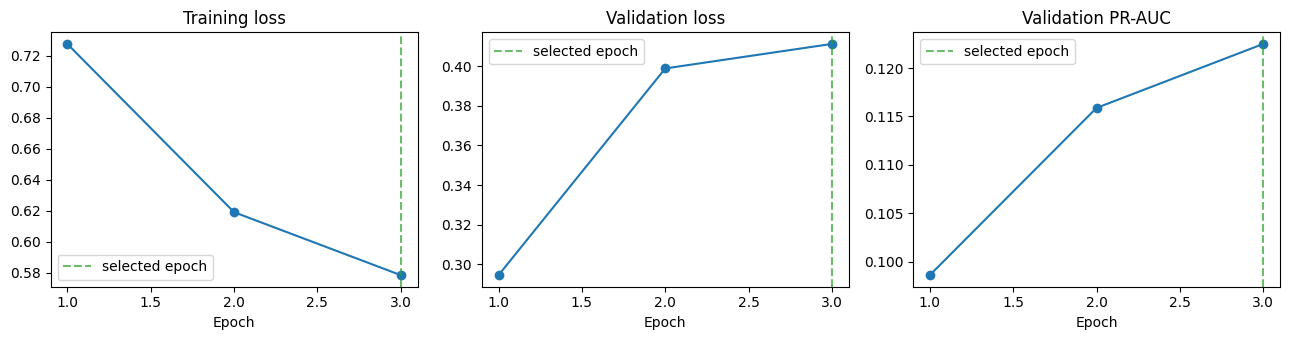

The selected checkpoint is epoch **3**, with validation PR-AUC **0.1225** and validation loss **0.4113**. A simple late-epoch overfitting signal was not present; the short run does not support stronger claims.

In [29]:
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

display(training_history)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for axis, column, title in zip(
    axes,
    ["training_loss", "validation_loss", "validation_pr_auc"],
    ["Training loss", "Validation loss", "Validation PR-AUC"],
):
    axis.plot(
        training_history["epoch"],
        training_history[column],
        marker="o",
    )
    
    axis.axvline(
        best_epoch,
        color="tab:green",
        linestyle="--",
        alpha=0.7,
        label="selected epoch",
    )
    
    axis.set(
        xlabel="Epoch",
        title=title,
    )
    
    axis.legend()

fig.tight_layout()
plt.show()

last_epoch = int(training_history["epoch"].iloc[-1])

overfit_signal = (
    last_epoch > best_epoch
    and training_history.loc[
        training_history["epoch"].eq(last_epoch),
        "validation_loss",
    ].iloc[0] > best_validation_loss
)

display(
    Markdown(
        f"The selected checkpoint is epoch **{best_epoch}**, "
        f"with validation PR-AUC **{best_validation_pr_auc:.4f}** "
        f"and validation loss **{best_validation_loss:.4f}**. "
        f"A simple late-epoch overfitting signal was "
        f"{'present' if overfit_signal else 'not present'}; "
        "the short run does not support stronger claims."
    )
)

### Reload the selected checkpoint before threshold selection

The last training epoch need not be the best epoch. The in-memory training model is released, then the saved Base + adapter + head is reconstructed. Predictions on a fixed validation probe must match those recorded when the checkpoint was written.

In [30]:
from peft import PeftModel


def load_saved_classifier(adapter_path: Path):
    "Rebuild Qwen3.5 with a two-logit head, then load the saved PEFT state."
    base_model, saved_processor = FastVisionModel.from_pretrained(
        MODEL_ID,
        load_in_4bit=False,
        load_in_16bit=True,
        max_seq_length=MAX_SEQ_LENGTH,
        use_gradient_checkpointing= False,
    )
    old_head = base_model.get_output_embeddings()
    reloaded_head = FP32ClassificationHead(
        old_head.in_features, 2, bias=False,
        device=old_head.weight.device, dtype=torch.float32,
    )
    base_model.set_output_embeddings(reloaded_head)
    base_model.config.num_labels = 2
    base_model.config.pad_token_id = getattr(saved_processor, "tokenizer", saved_processor).pad_token_id
    classifier = PeftModel.from_pretrained(base_model, adapter_path, is_trainable=False)
    classifier.config.use_cache = False
    return classifier, saved_processor


del model, optimiser, scheduler, scaler, trainable
torch.cuda.empty_cache()

model, processor = load_saved_classifier(BEST_ADAPTER_DIR)
text_tokenizer = getattr(processor, "tokenizer", processor)
text_tokenizer.padding_side = "right"
model.eval()

with torch.no_grad():
    reloaded_probe_probabilities = torch.softmax(
        final_token_logits(model, fixed_probe).float(), dim=1
    )[:, 1].cpu().numpy()

reload_max_absolute_difference = float(
    np.max(np.abs(reloaded_probe_probabilities - best_probe_probabilities))
)
RELOAD_VERIFIED = np.allclose(
    reloaded_probe_probabilities, best_probe_probabilities, rtol=1e-4, atol=1e-5
)
assert RELOAD_VERIFIED
print(f"Reload verification maximum probability difference: {reload_max_absolute_difference:.8f}")

==((====))==  Unsloth 2026.8.21: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
total weights      : 4.122 GiB
no_split classes   : ['Qwen3_5DecoderLayer', 'Qwen3_5TextDecoderLayer', 'Qwen3_5VisionBlock']
output head        : lm_head -> cuda:1
head headroom      : 0.428 GiB
activation reserve : 9.228 GiB requested
tied to head       : ['model.language_model.embed_tokens']
  cuda:0  budget  11.86 GiB  weights  2.542 GiB  free  9.315 GiB  reserve  9.228 GiB
  cuda:1  budget  11.15 GiB  weights  1.581 GiB  free  9.568 GiB  reserve  8.724 GiB   <- 

Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Reload verification maximum probability difference: 0.00000000


## 23. Validation Threshold Selection

The best checkpoint is now fixed. The MLP's established threshold rule is reused: maximise validation F1, then balanced accuracy, then proximity to 0.5, then the lower threshold. No test prediction is available at this stage.

In [31]:
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    log_loss,
)

validation_result = evaluate_classifier(model, validation_loader)
validation_threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.951, 0.01), 2):
    predictions = (validation_result["probabilities"] >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(validation_result["labels"], predictions, labels=[0, 1]).ravel()
    validation_threshold_rows.append({
        "threshold": float(threshold),
        "precision": precision_score(validation_result["labels"], predictions, zero_division=0),
        "recall": recall_score(validation_result["labels"], predictions, zero_division=0),
        "f1": f1_score(validation_result["labels"], predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(validation_result["labels"], predictions),
        "specificity": tn / (tn + fp),
        "distance_from_0_5": abs(float(threshold) - 0.5),
    })

validation_thresholds = pd.DataFrame(validation_threshold_rows)
selection_order = validation_thresholds.sort_values(
    ["f1", "balanced_accuracy", "distance_from_0_5", "threshold"],
    ascending=[False, False, True, True],
    kind="mergesort",
)
SELECTED_THRESHOLD = float(selection_order.iloc[0]["threshold"])
validation_thresholds["selected"] = validation_thresholds["threshold"].eq(SELECTED_THRESHOLD)
validation_thresholds.to_csv(RUN_RESULT_DIR / "validation_thresholds.csv", index=False)
(RUN_RESULT_DIR / "selected_threshold.json").write_text(
    json.dumps({"threshold": SELECTED_THRESHOLD, "source": "validation only"}, indent=2),
    encoding="utf-8",
)
display(selection_order.head(10))
print(f"Frozen validation-selected threshold: {SELECTED_THRESHOLD:.2f}")
assert not TEST_EVALUATION_STARTED

,threshold,precision,recall,f1,balanced_accuracy,specificity,distance_from_0_5
39,0.44,0.131617,0.405082,0.198680,0.595076,0.785070,0.06
38,0.43,0.125854,0.467862,0.198352,0.603266,0.738671,0.07
40,0.45,0.138226,0.337818,0.196181,0.584223,0.830629,0.05
37,0.42,0.119793,0.520179,0.194740,0.606405,0.692631,0.08
35,0.40,0.115526,0.612855,0.194405,0.617763,0.622671,0.10
36,0.41,0.116672,0.568012,0.193581,0.611089,0.654165,0.09
41,0.46,0.148988,0.275037,0.193277,0.574350,0.873663,0.04
29,0.34,0.109413,0.738416,0.190586,0.627532,0.516649,0.16
34,0.39,0.112019,0.635277,0.190455,0.615150,0.595023,0.11
33,0.38,0.111083,0.665172,0.190374,0.618558,0.571944,0.12


Frozen validation-selected threshold: 0.44


## 24. Final Test Evaluation

Only now, after the checkpoint, hyperparameters and threshold are fixed, is the test loader created. The test split is evaluated once. No later cell changes the trained model or threshold.

In [33]:
def compute_metrics(labels: np.ndarray, probabilities: np.ndarray, threshold: float) -> dict:
    "Return the project's binary utility metrics from fixed probabilities."
    predictions = (probabilities >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "n": int(len(labels)),
        "positive_count": int(labels.sum()),
        "prevalence": float(labels.mean()),
        "threshold": float(threshold),
        "pr_auc": float(average_precision_score(labels, probabilities)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, predictions)),
        "binary_cross_entropy": float(log_loss(labels, probabilities, labels=[0, 1])),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "auroc": float(roc_auc_score(labels, probabilities)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "specificity": float(tn / (tn + fp)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


TEST_EVALUATION_STARTED = True
test_loader = DataLoader(
    AssessmentTextDataset(split_frames["test"]), batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_assessments, num_workers=0,
)
test_result = evaluate_classifier(model, test_loader)
test_metrics = compute_metrics(
    test_result["labels"], test_result["probabilities"], SELECTED_THRESHOLD
)
display(pd.Series(test_metrics, name="Qwen3.5-2B test value").to_frame())

test_predictions = pd.DataFrame({
    "assessment_id": test_result["assessment_ids"],
    "label": test_result["labels"],
    "logit_0": test_result["logits"][:, 0],
    "logit_1": test_result["logits"][:, 1],
    "probability_class_1": test_result["probabilities"],
    "prediction": (test_result["probabilities"] >= SELECTED_THRESHOLD).astype(int),
})
test_predictions.to_csv(RUN_RESULT_DIR / "test_predictions.csv", index=False)
pd.DataFrame([test_metrics]).to_csv(RUN_RESULT_DIR / "test_metrics.csv", index=False)

,Qwen3.5-2B test value
n,8988.000000
positive_count,665.000000
prevalence,0.073988
threshold,0.440000
pr_auc,0.117037
balanced_accuracy,0.580828
binary_cross_entropy,0.409690
f1,0.185103
auroc,0.669940
precision,0.122618


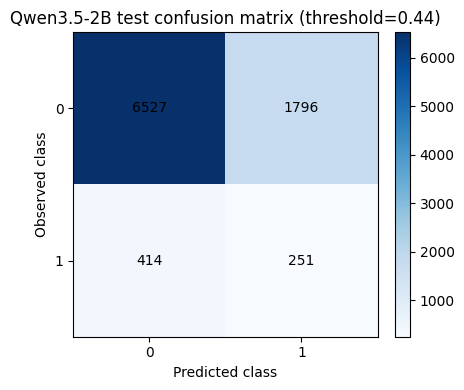

In [34]:
confusion = np.array([
    [test_metrics["true_negative"], test_metrics["false_positive"]],
    [test_metrics["false_negative"], test_metrics["true_positive"]],
])
fig, ax = plt.subplots(figsize=(4.5, 4))
image = ax.imshow(confusion, cmap="Blues")
for (row, column), value in np.ndenumerate(confusion):
    ax.text(column, row, str(value), ha="center", va="center")
ax.set(
    xticks=[0, 1], yticks=[0, 1],
    xlabel="Predicted class", ylabel="Observed class",
    title=f"Qwen3.5-2B test confusion matrix (threshold={SELECTED_THRESHOLD:.2f})",
)
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

## 25. Comparison with the Existing MLP

The MLP is not retrained. Its frozen test metrics are loaded from the existing baseline artefact and aligned with the Qwen outputs. Differences are reported neutrally; a larger language model is not assumed to be better for tabular data.

In [35]:
mlp_metrics = pd.read_csv(MLP_METRICS_PATH).iloc[0]
metric_labels = {
    "pr_auc": "PR-AUC",
    "balanced_accuracy": "Balanced Accuracy",
    "binary_cross_entropy": "BCE",
    "f1": "F1",
    "auroc": "AUROC",
}
comparison = pd.DataFrame([
    {
        "Metric": label,
        "MLP": float(mlp_metrics[key]),
        "Qwen3.5-2B": float(test_metrics[key]),
    }
    for key, label in metric_labels.items()
])
comparison.to_csv(RUN_RESULT_DIR / "mlp_qwen_test_comparison.csv", index=False)
display(comparison)

qwen_wins = int(sum(
    (row["Qwen3.5-2B"] > row["MLP"]) if row["Metric"] != "BCE"
    else (row["Qwen3.5-2B"] < row["MLP"])
    for _, row in comparison.iterrows()
))
display(Markdown(
    f"Qwen has the favourable value on **{qwen_wins} of 5** reported utility metrics. "
    "This comparison concerns predictive utility only; the Qwen model is substantially larger and more expensive than the MLP."
))

,Metric,MLP,Qwen3.5-2B
0,PR-AUC,0.168861,0.117037
1,Balanced Accuracy,0.630389,0.580828
2,BCE,0.575092,0.409690
3,F1,0.244579,0.185103
4,AUROC,0.732132,0.669940


Qwen has the favourable value on **1 of 5** reported utility metrics. This comparison concerns predictive utility only; the Qwen model is substantially larger and more expensive than the MLP.

## 26. Runtime and Resource Use

Runtime and peak allocated CUDA memory describe this Kaggle run, not a universal hardware benchmark. They support the later decision about whether the 2B classifier's cost is justified.


In [36]:
resource_summary = {
    "training runtime (minutes)": training_seconds / 60,
    "selected epoch": best_epoch,
    "selected epoch runtime (minutes)": float(
        training_history.loc[training_history["epoch"].eq(best_epoch), "epoch_seconds"].iloc[0] / 60
    ),
    "peak allocated GPU memory (GiB)": peak_gpu_memory_gib,
    "total parameters": total_parameters,
    "trainable parameters": trainable_parameters,
    "trainable percent": 100 * trainable_parameters / total_parameters,
    "GPU": environment_info["GPU"],
}
display(pd.Series(resource_summary, name="Value").to_frame())

,Value
training runtime (minutes),172.569861
selected epoch,3
selected epoch runtime (minutes),56.348341
peak allocated GPU memory (GiB),5.045837
total parameters,2236360512
trainable parameters,23114752
trainable percent,1.033588
GPU,Tesla T4


## 27. Save Final Artefacts

The PEFT adapter already contains the persisted `lm_head` because it was registered in `modules_to_save`. The head is also written separately for auditability. The remaining files below make feature order, text conversion, split membership, threshold, metrics and runtime explicit for a later notebook.

In [37]:
def save_experiment_config(path: Path) -> None:
    "Save the configuration needed to interpret and reproduce this run."
    config = {
        "run_id": RUN_ID,
        "model_id": MODEL_ID,
        "target": TARGET,
        "classes": {"0": "no acute rejection within 30 days", "1": "acute rejection within 30 days"},
        "feature_count": len(FEATURES),
        "serialisation_version": SERIALISATION_VERSION,
        "max_seq_length": MAX_SEQ_LENGTH,
        "training": training_configuration,
        "best_epoch": best_epoch,
        "selected_threshold": SELECTED_THRESHOLD,
        "selection_data": "validation only",
        "test_evaluations": 1,
        "machine_unlearning_performed": False,
    }
    path.write_text(json.dumps(config, indent=2), encoding="utf-8")


(RUN_RESULT_DIR / "feature_order.json").write_text(json.dumps(FEATURES, indent=2), encoding="utf-8")
(RUN_RESULT_DIR / "serialisation_specification.json").write_text(
    json.dumps({
        "version": SERIALISATION_VERSION,
        "feature_order": FEATURES,
        "display_labels": FEATURE_LABELS,
        "template": "{display_label}: {deterministically_formatted_value}.",
        "separator": "newline",
        "target_included": False,
        "identifiers_included": False,
    }, indent=2),
    encoding="utf-8",
)
split_assignments.to_csv(RUN_RESULT_DIR / "frozen_split_memberships.csv", index=False)
pd.DataFrame([{
    "validation_loss": validation_result["loss"],
    "validation_pr_auc": validation_result["pr_auc"],
    "selected_threshold": SELECTED_THRESHOLD,
}]).to_csv(RUN_RESULT_DIR / "validation_metrics.csv", index=False)
pd.DataFrame([resource_summary]).to_csv(RUN_RESULT_DIR / "runtime_resources.csv", index=False)
comparison.to_csv(RUN_RESULT_DIR / "mlp_qwen_test_comparison.csv", index=False)
save_experiment_config(RUN_RESULT_DIR / "experiment_configuration.json")

artefact_manifest = {
    "best_adapter_and_head": str(BEST_ADAPTER_DIR),
    "separate_head_state": str(RUN_MODEL_DIR / "binary_classification_head.pt"),
    "tokenizer_processor": str(BEST_ADAPTER_DIR),
    "configuration": str(RUN_RESULT_DIR / "experiment_configuration.json"),
    "feature_order": str(RUN_RESULT_DIR / "feature_order.json"),
    "serialisation": str(RUN_RESULT_DIR / "serialisation_specification.json"),
    "threshold": str(RUN_RESULT_DIR / "selected_threshold.json"),
    "split_memberships": str(RUN_RESULT_DIR / "frozen_split_memberships.csv"),
    "training_history": str(RUN_RESULT_DIR / "training_history.csv"),
    "validation_metrics": str(RUN_RESULT_DIR / "validation_metrics.csv"),
    "test_metrics": str(RUN_RESULT_DIR / "test_metrics.csv"),
    "test_predictions": str(RUN_RESULT_DIR / "test_predictions.csv"),
    "runtime": str(RUN_RESULT_DIR / "runtime_resources.csv"),
}
(RUN_RESULT_DIR / "artefact_manifest.json").write_text(
    json.dumps(artefact_manifest, indent=2), encoding="utf-8"
)
display(pd.Series(artefact_manifest, name="Saved path").to_frame())

,Saved path
best_adapter_and_head,/kaggle/working/qwen35_classifier_kaggle/model...
separate_head_state,/kaggle/working/qwen35_classifier_kaggle/model...
tokenizer_processor,/kaggle/working/qwen35_classifier_kaggle/model...
configuration,/kaggle/working/qwen35_classifier_kaggle/resul...
feature_order,/kaggle/working/qwen35_classifier_kaggle/resul...
serialisation,/kaggle/working/qwen35_classifier_kaggle/resul...
threshold,/kaggle/working/qwen35_classifier_kaggle/resul...
split_memberships,/kaggle/working/qwen35_classifier_kaggle/resul...
training_history,/kaggle/working/qwen35_classifier_kaggle/resul...
validation_metrics,/kaggle/working/qwen35_classifier_kaggle/resul...


## 28. Findings

The statements below are generated from this run rather than written in advance. “Learned signal” means that test AUROC exceeds 0.5 and PR-AUC exceeds test prevalence; it is not a claim of clinical usefulness.

In [38]:
finite_training = bool(np.isfinite(training_history[[
    "training_loss", "validation_loss", "validation_pr_auc"
]].to_numpy()).all())
learned_signal = bool(
    test_metrics["auroc"] > 0.5 and test_metrics["pr_auc"] > test_metrics["prevalence"]
)
competitive_with_mlp = qwen_wins >= 3
practical_on_kaggle = finite_training and peak_gpu_memory_gib < environment_info["GPU memory (GiB)"]

display(Markdown(
    f"- **Learned the task:** {'yes' if learned_signal else 'not established'} "
    f"(test AUROC {test_metrics['auroc']:.4f}; PR-AUC {test_metrics['pr_auc']:.4f}; "
    f"prevalence {test_metrics['prevalence']:.4f}).\n"
    f"- **Competitive with the MLP:** {'yes on the majority of listed metrics' if competitive_with_mlp else 'no on the majority of listed metrics'}.\n"
    f"- **Training stability:** {'all tracked values remained finite' if finite_training else 'a non-finite value was recorded'}.\n"
    f"- **Kaggle/Unsloth practicality:** {'the run fit the available GPU' if practical_on_kaggle else 'not established by this run'}; "
    f"training took {training_seconds / 60:.1f} minutes."
))

- **Learned the task:** yes (test AUROC 0.6699; PR-AUC 0.1170; prevalence 0.0740).
- **Competitive with the MLP:** no on the majority of listed metrics.
- **Training stability:** all tracked values remained finite.
- **Kaggle/Unsloth practicality:** the run fit the available GPU; training took 172.6 minutes.

## 29. Limitations

- Qwen3.5-2B is much larger and more computationally expensive than the MLP.
- Tabular fields must be converted to text, which may be less natural than direct numeric/categorical processing.
- Only one model size and one conservative training configuration are evaluated.
- A single Kaggle run does not establish variance across seeds or GPU types.
- This baseline does not test deletion or forgetting.
- The dataset is synthetic, so results do not establish clinical generalisability.

## 30. Readiness for Machine-Unlearning Extension

A later notebook may study Hospital Removal, Full Retraining, Gradient Difference, Truth Ratio, KS comparison, retained utility and runtime **only if** this baseline produces finite training, non-degenerate predictions and useful ranking signal. Those methods are not executed here.

In [39]:
READY_FOR_UNLEARNING_EXTENSION = bool(
    finite_training
    and learned_signal
    and len(np.unique(test_predictions["prediction"])) == 2
    and RELOAD_VERIFIED
)

display(Markdown(
    f"**Decision: {'ready for a separately designed machine-unlearning extension' if READY_FOR_UNLEARNING_EXTENSION else 'not yet ready for machine-unlearning'}**. "
    "A later notebook would reuse the Base model identifier, best LoRA adapter, saved two-class head, "
    "tokenizer, feature order, serialisation specification, frozen split memberships, validation threshold "
    "and baseline predictions saved above. No forgetting result is implied by this decision."
))

**Decision: ready for a separately designed machine-unlearning extension**. A later notebook would reuse the Base model identifier, best LoRA adapter, saved two-class head, tokenizer, feature order, serialisation specification, frozen split memberships, validation threshold and baseline predictions saved above. No forgetting result is implied by this decision.

## Final Verification

These checks make the notebook's methodological contract explicit. A failed assertion should be investigated rather than bypassed.

In [40]:
MACHINE_UNLEARNING_PERFORMED = False
completion_checks = pd.DataFrame([
    {"check": "CUDA was used", "pass": DEVICE.type == "cuda" and torch.cuda.is_available()},
    {"check": "Exact Qwen3.5-2B model used", "pass": MODEL_ID == "unsloth/Qwen3.5-2B-Base"},
    {"check": "Original frozen splits reused", "pass": ORIGINAL_SPLITS_REUSED},
    {"check": "No target or identifier leakage", "pass": NO_TARGET_LEAKAGE},
    {"check": "Exactly two logits produced", "pass": LOGITS_SHAPE_VERIFIED},
    {"check": "Classification head was trainable", "pass": head_was_trainable},
    {"check": "Test rows used for training = 0", "pass": TEST_ROWS_USED_FOR_TRAINING == 0},
    {"check": "Best checkpoint exists", "pass": BEST_ADAPTER_DIR.exists()},
    {"check": "Separate binary head state exists", "pass": (RUN_MODEL_DIR / "binary_classification_head.pt").exists()},
    {"check": "Frozen threshold exists", "pass": (RUN_RESULT_DIR / "selected_threshold.json").exists()},
    {"check": "Final metrics saved", "pass": (RUN_RESULT_DIR / "test_metrics.csv").exists()},
    {"check": "Saved classifier reload verified", "pass": RELOAD_VERIFIED},
    {"check": "Machine unlearning not performed", "pass": not MACHINE_UNLEARNING_PERFORMED},
])
assert completion_checks["pass"].all(), completion_checks.loc[~completion_checks["pass"]]
display(completion_checks)
print(f"Notebook 09 baseline complete. Persistent results: {RUN_RESULT_DIR}")

,check,pass
0,CUDA was used,True
1,Exact Qwen3.5-2B model used,True
2,Original frozen splits reused,True
3,No target or identifier leakage,True
4,Exactly two logits produced,True
5,Classification head was trainable,True
6,Test rows used for training = 0,True
7,Best checkpoint exists,True
8,Separate binary head state exists,True
9,Frozen threshold exists,True


Notebook 09 baseline complete. Persistent results: /kaggle/working/qwen35_classifier_kaggle/results/20260827T080825Z


## Kaggle Output Retention and GitHub Workflow

After a successful run, use **Save Version** in Kaggle and include notebook outputs so files under `/kaggle/working/qwen35_classifier_kaggle` are retained. You can also download that folder.

For future code changes: **Codex/local project → git commit/push → new Kaggle session → clone latest GitHub commit → run notebook**. Large Qwen checkpoints remain Kaggle outputs rather than normal GitHub files.


In [2]:
!ls /kaggle/working